In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dataset,info=tfds.load('plant_village',with_info=True,as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.9PBPQN_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.


In [3]:
train_data=dataset['train']

In [4]:
dataset_size=info.splits['train'].num_examples
train_size=int(0.8*dataset_size)

In [5]:
train_data=train_data.take(train_size)
test_data=dataset['train'].skip(train_size)

In [6]:
num_classes=info.features['label'].num_classes
class_names=info.features['label'].names
print(f"\nTotal classes:{num_classes}")
print(f"Classes:{class_names[:5]}")


Total classes:38
Classes:['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [7]:
img_size=128
batch_size=32

In [8]:
def preprocess_image(image, label):
    img=tf.image.resize(image,[img_size,img_size])
    img=tf.cast(img,tf.float32)
    img=img/255.0
    return img,label

In [9]:
def augment_image(image, label):
    img=tf.image.random_flip_left_right(image)
    img=tf.image.random_flip_up_down(image)
    img=tf.image.random_brightness(image,0.2)
    img=tf.image.random_contrast(image,0.8,1.2)
    return img,label

In [10]:
train_ds=train_data.map(preprocess_image)
train_ds=train_ds.map(augment_image)
train_ds=train_ds.shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [11]:
test_ds = test_data.map(preprocess_image)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [12]:
model = keras.Sequential([layers.Conv2D(32,(3,3),activation='relu',input_shape=(img_size,img_size,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
ds_train=train_ds.take(train_size)
ds_val=train_ds.skip(train_size)

In [14]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,134 (10.00 MB)

 Trainable params: 2,620,134 (10.00 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(train_ds,epochs=10,validation_data=test_ds,verbose=1)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 61s 44ms/step - accuracy: 0.9126 - loss: 0.2619 - val_accuracy: 0.9380 - val_loss: 0.1905
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 65s 47ms/step - accuracy: 0.9232 - loss: 0.2335 - val_accuracy: 0.9495 - val_loss: 0.1616
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 68s 49ms/step - accuracy: 0.9320 - loss: 0.2072 - val_accuracy: 0.9502 - val_loss: 0.1556
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 73s 43ms/step - accuracy: 0.9372 - loss: 0.1908 - val_accuracy: 0.9458 - val_loss: 0.1751
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 62s 45ms/step - accuracy: 0.9398 - loss: 0.1807 - val_accuracy: 0.9497 - val_loss: 0.1523
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 61s 44ms/step - accuracy: 0.9441 - loss: 0.1688 - val_accuracy: 0.9578 - val_loss: 0.1362
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 60s 44ms/step - accuracy: 0.9469 - loss: 0.1564 - val_accuracy: 0.9420 - val_loss: 0.1843
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 61s 44ms/step - accuracy: 0.9473 -

In [22]:
test_loss,test_accuracy=model.evaluate(test_ds)
print(f"Test Accuracy:{test_accuracy*100:.2f}%")

340/340 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.9557 - loss: 0.1375
Test Accuracy:95.83%


In [23]:
model.save('plant_disease_model.h5')

In [24]:
def predict_disease(image_path):
    img=tf.keras.preprocessing.image.load_img(image_path,target_size=(img_size,img_size))
    img_array=tf.keras.preprocessing.image.img_to_array(img)
    img_array=img_array/255.0
    img_array=tf.expand_dims(img_array,0)
    predictions=model.predict(img_array,verbose=0)
    predicted_class=np.argmax(predictions[0])
    confidence=predictions[0][predicted_class]
    predicted_label=class_names[predicted_class]
    is_healthy='healthy' in predicted_label.lower()
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    if is_healthy:
        status="HEALTHY"
        color='green'
        disease="No disease detected"
    else:
        status="DISEASED"
        color='red'
        disease=predicted_label.replace('_', ' ').title()
    plt.title(f"Status:{status}\nDisease:{disease}\nConfidence:{confidence*100:.2f}%",fontsize=14,color=color,weight='bold')
    plt.tight_layout()
    plt.show()
    result = {
        'status':status,
        'disease':disease,
        'confidence':float(confidence * 100),
        'predicted_class':predicted_label
    }
    print(f"Status:{status}")
    print(f"Disease:{disease}")
    print(f"Confidence:{confidence*100:.2f}%")
    return result


Saving pepper unhealthy.jpeg to pepper unhealthy.jpeg

Image 'pepper unhealthy.jpeg' uploaded successfully



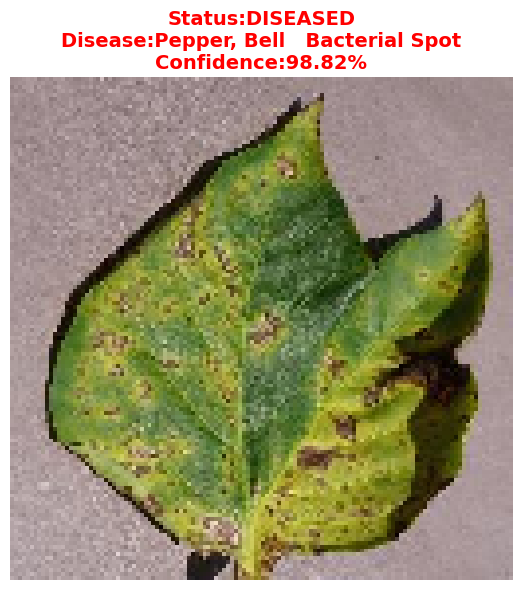

Status:DISEASED
Disease:Pepper, Bell   Bacterial Spot
Confidence:98.82%


In [25]:
from google.colab import files
uploaded = files.upload()
for filename in uploaded.keys():
    image_path=filename
    print(f"\nImage '{filename}' uploaded successfully\n")
    predict_disease(image_path)